# Imports y Análisis inicial

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [84]:
df = pd.read_csv('uber_fares.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(10)

Dimensiones del dataset: 200000 filas x 9 columnas


,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.4700,2015-05-07 19:50:00 UTC,-73.9998,40.7384,-73.9995,40.7232,1
1,27835199,2009-07-17 20:00:04,7.6000,2009-07-17 20:00:04 UTC,-73.9944,40.7282,-73.9947,40.7503,1
2,44984355,2009-08-24 21:49:07,12.6500,2009-08-24 21:49:07 UTC,-74.0050,40.7408,-73.9626,40.7726,1
3,25894730,2009-06-26 08:17:45,5.0100,2009-06-26 08:17:45 UTC,-73.9761,40.7908,-73.9653,40.8033,3
4,17610152,2014-08-28 17:46:18,15.6400,2014-08-28 17:46:18 UTC,-73.9250,40.7441,-73.9731,40.7612,5
5,44470845,2011-02-12 02:28:47,4.0500,2011-02-12 02:28:47 UTC,-73.9690,40.7559,-73.9690,40.7559,1
6,48725865,2014-10-12 07:01:25,26.7300,2014-10-12 07:01:25 UTC,-73.9614,40.6940,-73.8712,40.7743,5
7,44195482,2012-12-11 13:53:11,2.7000,2012-12-11 13:53:11 UTC,0.0000,0.0000,0.0000,0.0000,1
8,15822268,2012-02-17 09:34:14,9.5000,2012-02-17 09:34:14 UTC,-73.9752,40.7458,-74.0027,40.7435,1
9,50611056,2012-03-29 19:03:22,12.5300,2012-03-29 19:03:22 UTC,-74.0011,40.7418,-73.9630,40.7750,1


In [85]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 50)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


Parece que tenemos todas columnas numéricas, salvo 2 que se intencionan como datetime pero con la carga existen como string. También hay 2 valores nulos en todo el dataset: uno en `dropoff_latitude` y otro en `dropoff_longitude`.

In [86]:
# Filtramos el dataframe para mostrar solo las filas que tienen al menos un valor nulo
filas_nulas = df[df.isnull().any(axis=1)]

print("Filas con valores faltantes:")
filas_nulas

Filas con valores faltantes:


,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:53:05,24.1500,2013-07-02 03:53:05 UTC,-73.9506,40.7797,NaN,NaN,0


Parece ser una fila rara, que no tiene pasajeros, a pesar de existir una tarifa por ese viaje. Es una sola fila y que tiene varios problemas, así que la eliminamos.

In [87]:
df.dropna(inplace=True)

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['date'] = pd.to_datetime(df['date'])

print(df[['date', 'pickup_datetime']].dtypes)
print('=' * 50)
df.info()
print('=' * 80)
df.head()

date                    datetime64[us]
pickup_datetime    datetime64[us, UTC]
dtype: object
<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199999 non-null  int64              
 1   date               199999 non-null  datetime64[us]     
 2   fare_amount        199999 non-null  float64            
 3   pickup_datetime    199999 non-null  datetime64[us, UTC]
 4   pickup_longitude   199999 non-null  float64            
 5   pickup_latitude    199999 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    199999 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 15.3 MB


,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.4700,2015-05-07 19:50:00+00:00,-73.9998,40.7384,-73.9995,40.7232,1
1,27835199,2009-07-17 20:00:04,7.6000,2009-07-17 20:00:04+00:00,-73.9944,40.7282,-73.9947,40.7503,1
2,44984355,2009-08-24 21:49:07,12.6500,2009-08-24 21:49:07+00:00,-74.0050,40.7408,-73.9626,40.7726,1
3,25894730,2009-06-26 08:17:45,5.0100,2009-06-26 08:17:45+00:00,-73.9761,40.7908,-73.9653,40.8033,3
4,17610152,2014-08-28 17:46:18,15.6400,2014-08-28 17:46:18+00:00,-73.9250,40.7441,-73.9731,40.7612,5


In [88]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
key,27712478.5647,27745245.0000,16013858.3080,57.7857,1.0000,13825336.5000,27745245.0000,41555348.5000,55423567.0000,-0.0018,-1.2003
fare_amount,11.3629,8.4300,9.9432,87.5065,1.0000,5.9700,8.4300,12.6600,503.1300,4.4823,62.2469
pickup_longitude,-72.5276,-73.9818,11.4378,-15.7703,-1340.6484,-73.9921,-73.9818,-73.9672,57.4185,-7.4959,1144.0219
pickup_latitude,39.9359,40.7526,7.7206,19.3324,-74.0155,40.7348,40.7526,40.7672,1644.4215,62.9767,12869.1778
dropoff_longitude,-72.5253,-73.9801,13.1174,-18.0867,-3356.6663,-73.9914,-73.9801,-73.9637,1153.5726,-71.5051,20078.7229
dropoff_latitude,39.9239,40.7530,6.7948,17.0195,-881.9855,40.7338,40.7530,40.7680,872.6976,-8.0310,2981.7419
passenger_count,1.6845,1.0000,1.3860,82.2772,0.0000,1.0000,1.0000,2.0000,208.0000,18.1457,2456.6454


`passenger_count` no puede ser 0. Hay que revisar cuantas son con pasajeros 0, y qué pasaba en esas filas. Además, las longitudes deben estar entre -180 y 180, y las latitudes entre -90 y 90. Hay que analizar todas las filas que están fuera de este rango.

Vamos a definir una función `haversine` que nos va a permitir calcular la distancia de los recorridos de cada viaje. Añadiremos una nueva columna con esta información, ya que la utilizaremos más adelante tanto para análisis como para limpieza.

In [89]:
def haversine(lat1, lon1, lat2, lon2):
    r = 6371  # km
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return r * c

In [90]:
df["dist_km"] = haversine(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)

# Limpieza de datos

#### Análisis cantidad de pasajeros
Como se mencionó anteriormente, no tiene sentido que `passanger_count` sea 0. Procedemos a analizar qué porcentaje del dataset contiene estos valores:

In [91]:
pc0 = df[df["passenger_count"] == 0]

print("Cantidad:", len(pc0))
print("Porcentaje:", len(pc0) / len(df) * 100)

Cantidad: 708
Porcentaje: 0.35400177000885


El porcentaje es 0.35%, un valor muy bajo. Analizamos otras métricas:

In [92]:
# Coordenadas en 0
coords_0 = pc0[
    (pc0["pickup_longitude"] == 0) |
    (pc0["pickup_latitude"] == 0) |
    (pc0["dropoff_longitude"] == 0) |
    (pc0["dropoff_latitude"] == 0)
]

print("Casos con passenger_count=0 y alguna coordenada en 0:", len(coords_0))

Casos con passenger_count=0 y alguna coordenada en 0: 22


In [93]:
pc0["year"] = pd.to_datetime(pc0["pickup_datetime"]).dt.year
print(pc0["year"].value_counts().sort_index())

year
2009      1
2010     13
2011    454
2012    229
2013      1
2014      4
2015      6
Name: count, dtype: int64


Si bien se observa que algunos casos `passanger_count` es cero y alguna coordenada también, estos valores son pocos comparados con el dataset y no nos brindan mucha más información como para imputar datos. Siendo que solo el 0.35% del dataset contiene estos valores inválidos, procedemos a eliminarlos. 

In [94]:
df_limpio = df[df["passenger_count"] > 0].copy()

#### Análisis coordenadas

In [95]:
coords_invalidas = df[ (df["pickup_longitude"] < -180) | (df["pickup_longitude"] > 180) | (df["dropoff_longitude"] < -180) | (df["dropoff_longitude"] > 180) | (df["pickup_latitude"] < -90) | (df["pickup_latitude"] > 90) | (df["dropoff_latitude"] < -90) | (df["dropoff_latitude"] > 90) ]
print("Cantidad de filas con coordenadas fuera de rango:", len(coords_invalidas))
print("Porcentaje:", len(coords_invalidas) / len(df) * 100)

Cantidad de filas con coordenadas fuera de rango: 12
Porcentaje: 0.006000030000150001


In [96]:
df_limpio = df_limpio[
    (df_limpio["pickup_longitude"].between(-180, 180)) &
    (df_limpio["dropoff_longitude"].between(-180, 180)) &
    (df_limpio["pickup_latitude"].between(-90, 90)) &
    (df_limpio["dropoff_latitude"].between(-90, 90))
].copy()

Analizamos el porcentaje de las filas con coordenadas inválidas y se observa que es insignificante, por lo que decidimos removerlas.

#### Análisis distancia recorrida

In [107]:
print(df_limpio["dist_km"].describe())
print(df_limpio["dist_km"].quantile([0.90, 0.95, 0.99, 0.999]))

count   199279.0000
mean        20.4057
std        377.8204
min          0.0000
25%          1.2153
50%          2.1216
75%          3.8758
max       8782.8986
Name: dist_km, dtype: float64
0.9000      7.0223
0.9500     10.1101
0.9900     20.7142
0.9990   8665.3455
Name: dist_km, dtype: float64


Como se puede ver, el std es muy alto, y se observa un valor máximo atípico. Nuestra primer sospecha se relaciona con las coordenadas iguales a 0, ya que algunas pueden ser inválidas. Vamos a analizar la relación entre estas y las distancias más extremas:

In [ ]:
coords_cero = df_limpio[
    (df_limpio["pickup_longitude"] == 0) |
    (df_limpio["pickup_latitude"] == 0) |
    (df_limpio["dropoff_longitude"] == 0) |
    (df_limpio["dropoff_latitude"] == 0)
]

coords_cero[[
        "key",
        "pickup_longitude", "pickup_latitude",
        "dropoff_longitude", "dropoff_latitude",
        "dist_km"
    ]].sort_values("dist_km", ascending=False)


,key,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,dist_km
65591,10503111,0.0000,0.0000,-75.3956,40.7415,8782.8986
34594,50815502,0.0000,0.0000,-75.3347,40.6487,8776.1063
140620,38849731,-73.9913,40.7393,0.0000,-0.5633,8708.2331
165324,5178341,0.0000,0.0000,-74.1815,40.6878,8681.1059
145538,25350901,0.0000,0.0000,-74.1769,40.6947,8680.8639
...,...,...,...,...,...,...
72272,4242034,0.0000,0.0000,0.0000,0.0000,0.0000
72275,54318816,0.0000,0.0000,0.0000,0.0000,0.0000
72314,23026820,0.0000,0.0000,0.0000,0.0000,0.0000
72408,20074698,0.0000,0.0000,0.0000,0.0000,0.0000


In [ ]:
print("Cantidad:", len(coords_cero))
print("Porcentaje:", len(coords_cero) / len(df_limpio) * 100)

Cantidad: 3946
Porcentaje: 1.980138398928136
count   3946.0000
mean     808.9164
std     2503.2837
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max     8782.8986
Name: dist_km, dtype: float64


Parece haber una relación entre viajes con distancias muy grandes y las coordenadas con valores 0. También observamos uan relación entre estas coordenadas y los viajes con distancia 0, así que decidimos eliminar estos registros.

In [115]:
df_limpio = df_limpio[
    (df_limpio["pickup_longitude"] != 0) &
    (df_limpio["pickup_latitude"] != 0) &
    (df_limpio["dropoff_longitude"] != 0) &
    (df_limpio["dropoff_latitude"] != 0)
].copy()

In [116]:
print(df_limpio["dist_km"].describe())
print(df_limpio["dist_km"].quantile([0.90, 0.95, 0.99, 0.999]))

count   195333.0000
mean         4.4767
std         79.1125
min          0.0000
25%          1.2555
50%          2.1572
75%          3.9106
max       8667.6932
Name: dist_km, dtype: float64
0.9000    7.0276
0.9500   10.0406
0.9900   20.4343
0.9990   26.2127
Name: dist_km, dtype: float64


De todas formas, seguimos detectando outliers (el valor max es de 8667km). Seguimos analizando:

In [139]:
df_limpio.sort_values("dist_km", ascending=False).head(150)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist_km
70889,32607506,2009-06-02 16:34:48,4.5100,2009-06-02 16:34:48+00:00,-73.9996,40.7682,0.0002,-0.0000,1,8667.6932
129303,20317514,2012-05-11 13:37:59,11.2500,2012-05-11 13:37:59+00:00,-0.1283,0.9668,-74.0006,40.7627,1,8585.3292
52972,23859685,2012-08-07 11:27:38,9.3400,2012-08-07 11:27:38+00:00,-73.9871,40.6879,-0.0500,40.7125,6,6032.1762
11880,16955954,2012-02-26 00:01:06,14.3700,2012-02-26 00:01:06+00:00,-0.0077,40.7256,-73.9675,40.7664,5,6029.4007
144073,37980386,2012-05-27 13:24:42,5.5300,2012-05-27 13:24:42+00:00,-73.9973,40.7315,-0.0667,40.7290,1,6028.7382
...,...,...,...,...,...,...,...,...,...,...
110500,4395702,2014-05-01 23:41:00,97.8900,2014-05-01 23:41:00+00:00,-73.8640,40.7699,-74.1124,40.5788,1,29.8328
170944,51877375,2013-05-19 20:55:18,69.2800,2013-05-19 20:55:18+00:00,-73.8730,40.7741,-73.5205,40.7830,1,29.7014
126783,14780497,2013-09-11 06:10:57,75.7300,2013-09-11 06:10:57+00:00,-73.7768,40.6455,-73.9116,40.8920,1,29.6734
58044,20059639,2014-12-15 20:45:39,140.0300,2014-12-15 20:45:39+00:00,-73.8771,40.7727,-73.6719,40.9894,1,29.6269


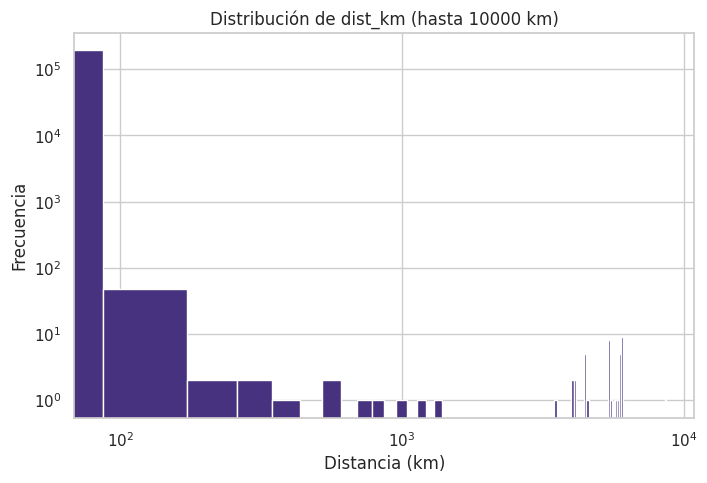

In [150]:
plt.figure(figsize=(8,5))
plt.hist(df_limpio[df_limpio["dist_km"] <= 10000]["dist_km"], bins=100)
plt.xlabel("Distancia (km)")
plt.ylabel("Frecuencia")
plt.yscale('log')
plt.xscale('log')
plt.title("Distribución de dist_km (hasta 10000 km)")
plt.show()

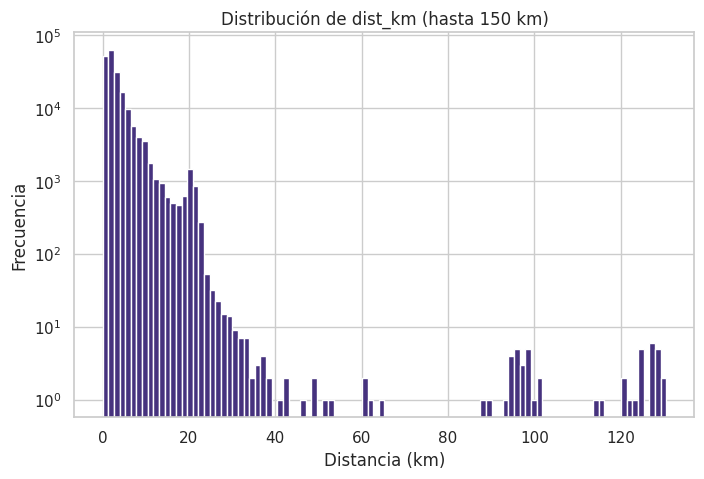

In [151]:
plt.figure(figsize=(8,5))
plt.hist(df_limpio[df_limpio["dist_km"] <= 150]["dist_km"], bins=100)
plt.xlabel("Distancia (km)")
plt.ylabel("Frecuencia")
plt.yscale('log')
#plt.xscale('log')
plt.title("Distribución de dist_km (hasta 150 km)")
plt.show()

Observamos que siguen existiendo pocas distancias con mucho valor (arriba de los 1000km) que parecen venir de tener latitud o longitudes que tienden a 0. Al mirar la distribución completa empiezan a haber varios valores acumulados un poco por abajo de los 150km, así que decidimos este valor como cota, ya que arriba del mismo, los valores atípicos son aislados. 

In [152]:
df_limpio = df_limpio[df_limpio["dist_km"] <= 150].copy()

In [153]:
print(df_limpio["dist_km"].describe())
print(df_limpio["dist_km"].quantile([0.90, 0.95, 0.99, 0.999]))

count   195281.0000
mean         3.3441
std          3.9832
min          0.0000
25%          1.2554
50%          2.1566
75%          3.9090
max        130.5424
Name: dist_km, dtype: float64
0.9000    7.0171
0.9500   10.0214
0.9900   20.3882
0.9990   24.0822
Name: dist_km, dtype: float64


# Visualizaciones (Histogramas, Boxplots y Scatterplots)

In [157]:
df_plot = df_limpio

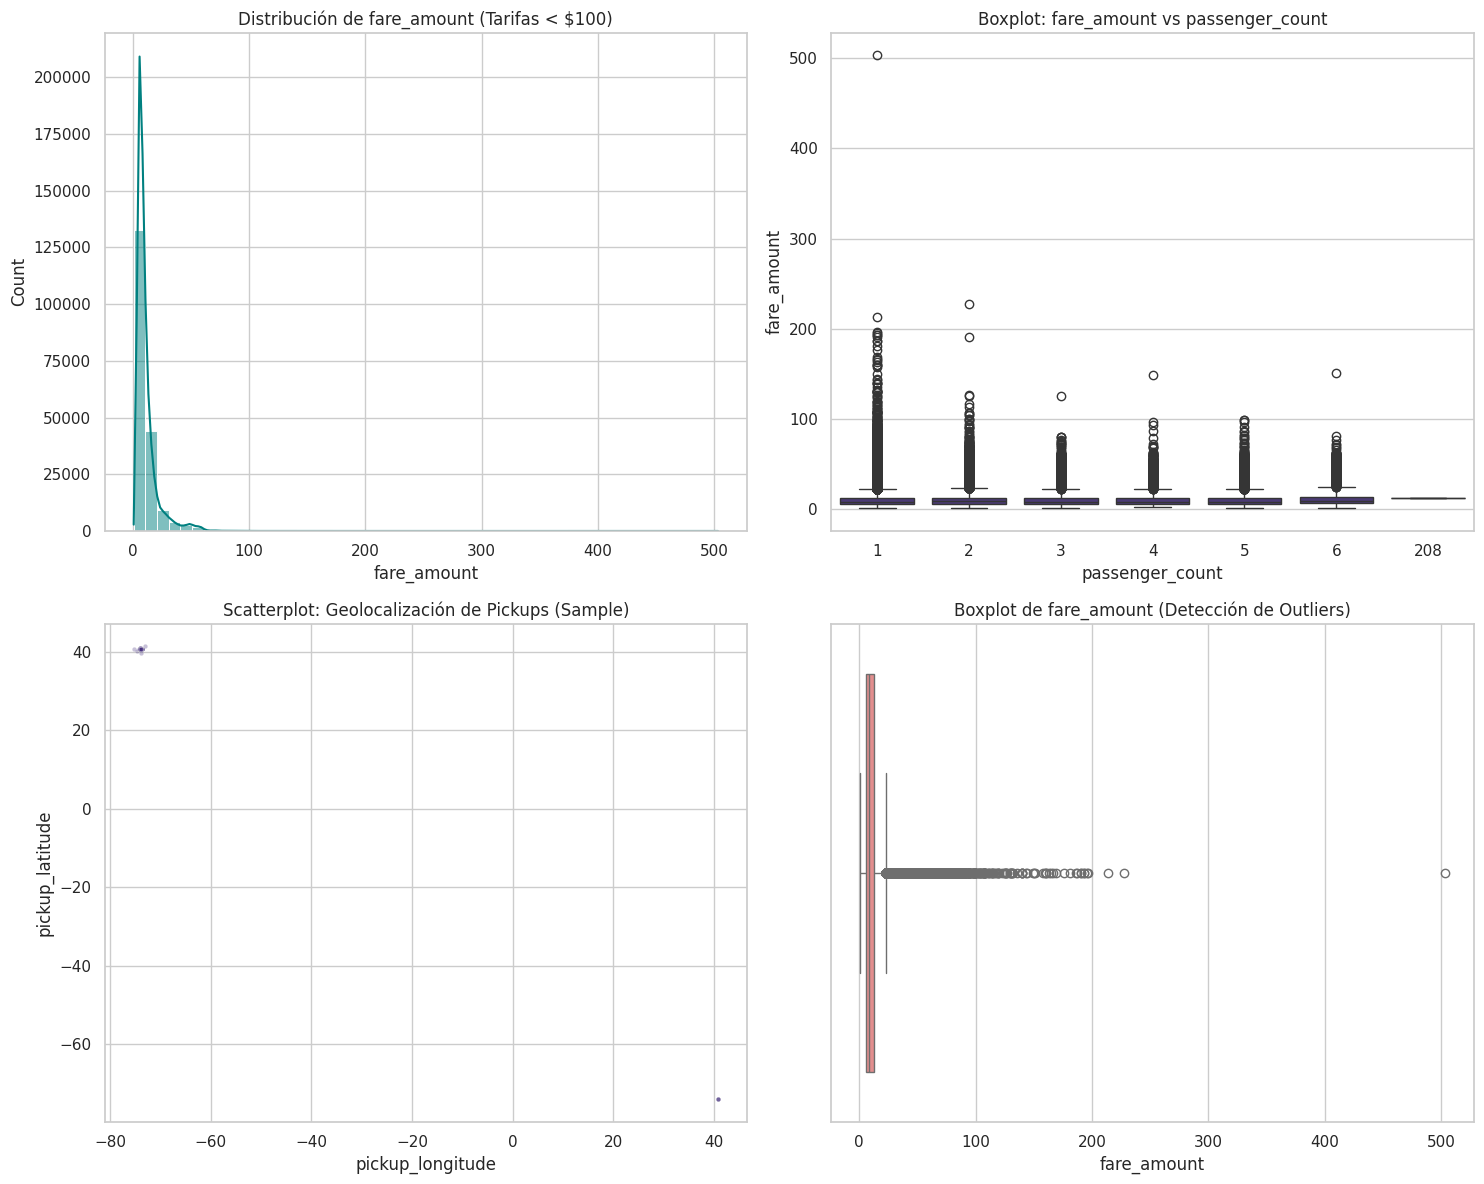

In [158]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histograma: Distribución de la Tarifa
sns.histplot(df_plot['fare_amount'], bins=50, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribución de fare_amount (Tarifas < $100)')

# 2. Boxplot: Tarifa por cantidad de pasajeros
sns.boxplot(x='passenger_count', y='fare_amount', data=df_plot, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot: fare_amount vs passenger_count')

# 3. Scatterplot: Relación entre ubicación (Pickup)
# Usamos un sample para no saturar el gráfico
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df_plot.sample(5000), 
                alpha=0.3, ax=axes[1, 0], s=10)
axes[1, 0].set_title('Scatterplot: Geolocalización de Pickups (Sample)')

# 4. Boxplot: Detección de outliers en fare_amount
sns.boxplot(x=df_plot['fare_amount'], ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Boxplot de fare_amount (Detección de Outliers)')

plt.tight_layout()
plt.show()

**3. Matriz de Correlación**

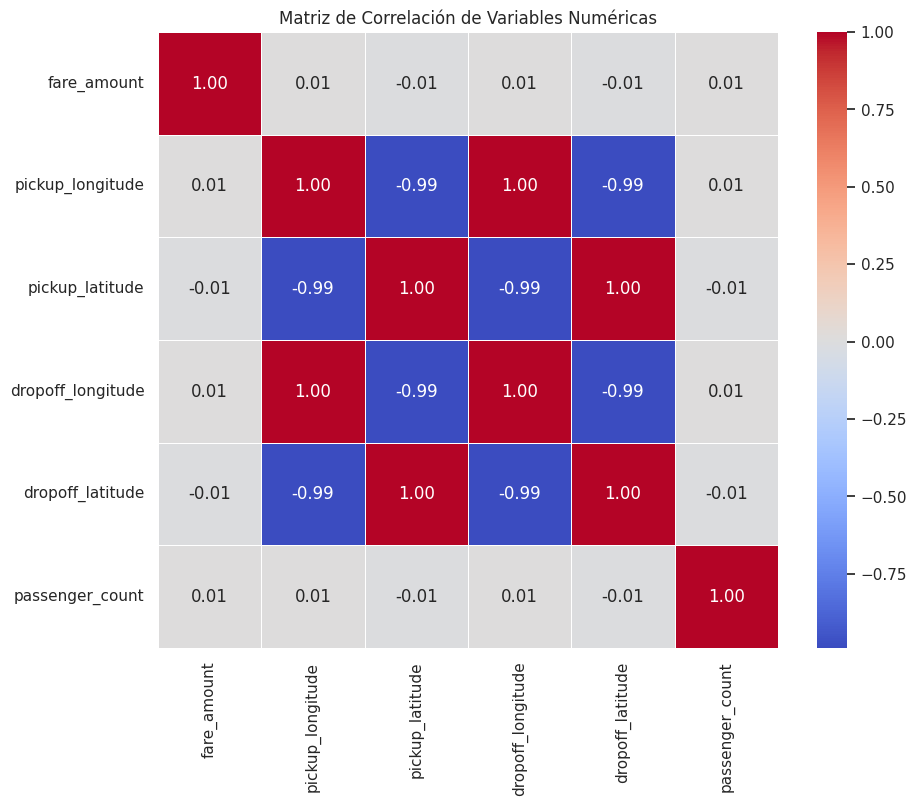

In [159]:
#La correlación nos dirá qué variables numéricas se mueven juntas.

plt.figure(figsize=(10, 8))

# Calculamos correlación solo de columnas numéricas relevantes
corr_matrix = df_plot[['fare_amount', 'pickup_longitude', 'pickup_latitude', 
                       'dropoff_longitude', 'dropoff_latitude', 'passenger_count']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Notas sobre los resultados:**
**Histograma:** Hay un sesgo a la derecha es normal en precios, muchos viajes baratos y pocos muy caros

**Boxplots:** Ayuda a confirmar si el número de pasajeros influye realmente en el costo (En Uber no suele influir tanto como la distancia).

**Correlación:** Se ven correlaciones bajas entre coordenadas y tarifa directamente.